# Datos meteorológicos de Tenerefife de la estación Ecomuseo

In [299]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
from pandas import json_normalize 
from pprint import pprint 

%matplotlib inline

Vamos a analizar los datos meteorológicos del mes de Abril de Tenerife recogidos en la estación Ecomuseo. Primero exploraremos el dataset sin manipularlo para conocer qué datos hemos recogido. Estos datos los vamos a coger de la web directamente con una API para tener ayor catidad de datos y que se actualice siempre que se ejecute este notebook.

In [300]:
#URL de los datos que queremos extraer
base_url = 'https://datos.tenerife.es/api/meteo/latest/readings/summarized/station/1/year/'

#Hacemos un GET para obtener los datos
def get_data_year(year):
    url = f"{base_url}/{year}"
    data_url = requests.get(url)
    print(data_url)
    # Verificar que la solicitud fue exitosa
    if data_url.status_code == 200:
        data_json = data_url.json()
        print(data_json)
    else:
        print(f"Error: {data_url.status_code}")

#Elegimos el año que queremos extraer
year_data = "2026"
year_info=get_data_year(year_data)


<Response [200]>
{'summarized': {'id_weatherstation': 1, 'sensors': [{'id_weatherstationsensor': 280, 'dates': [{'observation_date': '2026-01-01', 'is_validated': True, 'values': [{'mean': 5.6847224, 'min': 0.4, 'max': 9.3, 'total': ''}]}, {'observation_date': '2026-01-02', 'is_validated': True, 'values': [{'mean': 4.9381943, 'min': 0.4, 'max': 12.0, 'total': ''}]}, {'observation_date': '2026-01-03', 'is_validated': True, 'values': [{'mean': 1.6743056, 'min': 0.2, 'max': 4.6, 'total': ''}]}, {'observation_date': '2026-01-04', 'is_validated': True, 'values': [{'mean': 1.5166667, 'min': 0.0, 'max': 3.8, 'total': ''}]}, {'observation_date': '2026-01-05', 'is_validated': True, 'values': [{'mean': 3.2319446, 'min': 0.1, 'max': 9.0, 'total': ''}]}, {'observation_date': '2026-01-06', 'is_validated': True, 'values': [{'mean': 6.858333, 'min': 2.6, 'max': 10.0, 'total': ''}]}, {'observation_date': '2026-01-07', 'is_validated': True, 'values': [{'mean': 7.15, 'min': 4.3, 'max': 10.3, 'total': ''

In [301]:
resumen = data_json["summarized"]

filas = []

for sensor in resumen["sensors"]:
    sensor_id = sensor["id_weatherstationsensor"]

    for fecha in sensor["dates"]:
        fecha_obs = fecha["observation_date"]

        for valores in fecha["values"]:

            metricas = {
                "total": valores.get("total"),
                "media": valores.get("mean"),
                "minimo": valores.get("min"),
                "maximo": valores.get("max")
            }

            for metrica, valor in metricas.items():
                filas.append({
                    "estacion_id": resumen["id_weatherstation"],
                    "sensor_id": sensor_id,
                    "fecha_observacion": fecha_obs,
                    "metrica": metrica,
                    "valor": valor
                })

df_ecomuseo = pd.DataFrame(filas)

In [302]:
#Veamos las estadísticas del dataset
df_ecomuseo.describe()

#Tipos de los datos
df_ecomuseo.dtypes
df_ecomuseo.columns
df_ecomuseo.info()

#Dimensiones del dataset
print("Filas:", df_ecomuseo.shape[0])
print("Columnas:", df_ecomuseo.shape[1])

#Ver el dataset
df_ecomuseo

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   estacion_id        4240 non-null   int64 
 1   sensor_id          4240 non-null   int64 
 2   fecha_observacion  4240 non-null   object
 3   metrica            4240 non-null   object
 4   valor              4240 non-null   object
dtypes: int64(2), object(3)
memory usage: 165.8+ KB
Filas: 4240
Columnas: 5


,estacion_id,sensor_id,fecha_observacion,metrica,valor
0,1,280,2026-01-01,total,
1,1,280,2026-01-01,media,5.684722
2,1,280,2026-01-01,minimo,0.4
3,1,280,2026-01-01,maximo,9.3
4,1,280,2026-01-02,total,
...,...,...,...,...,...
4235,1,288,2026-07-30,maximo,
4236,1,288,2026-07-31,total,
4237,1,288,2026-07-31,media,
4238,1,288,2026-07-31,minimo,


Se puede ver que hay varios datos de valores(totales, medias, mínimos) que no tienen datos. Esto es importante porque una columna con más de un 40% de missing es una columna inservible para hacer cálculos ya que aunque quisiéramos "arreglar" el dataset sustituyendo los missings por la media, por el valor esperado para ese registro o ignoramos esos registros, son una cantidad considerable que altera completamente el análisis y se suele eliminar ese feature del análisis.

Además, en los formatos de los campos de nuestro dataset podemos observar que fecha_onbservacion es tipo object y no tipo datetime. Tenemos qu cambiar el formato.

Vamos a analizar cuántos missings, su proporción en el dataset y la cardinalidad.

In [303]:
def data_report(df_ecomuseo):
    # Sacamos los NOMBRES
    cols = pd.DataFrame(df_ecomuseo.columns.values, columns=["COL_N"])

    # Sacamos los TIPOS
    types = pd.DataFrame(df_ecomuseo.dtypes.values, columns=["DATA_TYPE"])

    # Sacamos los MISSINGS
    percent_missing = round(df_ecomuseo.isnull().sum() * 100 / len(df_ecomuseo), 2)
    percent_missing_df = pd.DataFrame(percent_missing.values, columns=["MISSINGS (%)"])

    # Sacamos los VALORES UNICOS
    unicos = pd.DataFrame(df_ecomuseo.nunique().values, columns=["UNIQUE_VALUES"])
    
    percent_cardin = round(unicos['UNIQUE_VALUES']*100/len(df_ecomuseo), 2)
    percent_cardin_df = pd.DataFrame(percent_cardin.values, columns=["CARDINAL (%)"])

    concatenado = pd.concat([cols, types, percent_missing_df, unicos, percent_cardin_df], axis=1, sort=False)
    concatenado.set_index('COL_N', drop=True, inplace=True)


    return concatenado.T
        
data_report(df_ecomuseo)

COL_N,estacion_id,sensor_id,fecha_observacion,metrica,valor
DATA_TYPE,int64,int64,object,object,object
MISSINGS (%),0.0,0.0,0.0,0.0,0.0
UNIQUE_VALUES,1,5,212,4,1371
CARDINAL (%),0.02,0.12,5.0,0.09,32.33


In [304]:
#Cambiamos formato fecha a datetime
df_ecomuseo['fecha_observacion'] = pd.to_datetime(df_ecomuseo['fecha_observacion'])
df_ecomuseo['valor'] = pd.to_numeric(df_ecomuseo['valor'])
df_ecomuseo.dtypes

estacion_id                   int64
sensor_id                     int64
fecha_observacion    datetime64[ns]
metrica                      object
valor                       float64
dtype: object

# Los diferentes sensores son:

WSP - Velocidad del viento - 1422

TEMP - Temperatura - 1424

HUM - Humedad relativa - 1425

RAIN - Precipitaciones - 1426

RAD - Radiación solar - 1431


Para hacer un análisis de los datos vamos a visualizar las medidas por fecha. Para ello primero vamos a dividir el df para cada sensor y comparar estos datos en un gráfico. Dividimos el dataset en varios subdataset porque si no no podemos realmente ver el valor de cada uno distinto y se pueden mezclar datos, separar los dataset nos permite analizar de forma clara y diferenciada cada tipo de medida.

In [305]:
#Primero nos deshacemos de las columnas que no nos interesan(valores repetidos o irrelevantes)

#Vamos vamos a dividir el dataset
df_sensor280 = df_ecomuseo[df_ecomuseo['sensor_id'] == 280]
df_sensor282 = df_ecomuseo[df_ecomuseo['sensor_id'] == 282]
df_sensor283 = df_ecomuseo[df_ecomuseo['sensor_id'] == 283]
df_sensor285 = df_ecomuseo[df_ecomuseo['sensor_id'] == 285]
df_sensor288 = df_ecomuseo[df_ecomuseo['sensor_id'] == 288]

#Vamos a deshacernos de las columnas que no nos interesan(valores repetidos o irrelevantes)
df_sensor280.drop(columns=['estacion_id', 'sensor_id'], inplace=True)
df_sensor282.drop(columns=['estacion_id', 'sensor_id'], inplace=True)
df_sensor283.drop(columns=['estacion_id', 'sensor_id'], inplace=True)
df_sensor285.drop(columns=['estacion_id', 'sensor_id'], inplace=True)
df_sensor288.drop(columns=['estacion_id', 'sensor_id'], inplace=True)

C:\Users\Inesita Bonita\AppData\Local\Temp\ipykernel_7852\2940666056.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sensor280.drop(columns=['estacion_id', 'sensor_id'], inplace=True)
C:\Users\Inesita Bonita\AppData\Local\Temp\ipykernel_7852\2940666056.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sensor282.drop(columns=['estacion_id', 'sensor_id'], inplace=True)
C:\Users\Inesita Bonita\AppData\Local\Temp\ipykernel_7852\2940666056.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-doc

In [306]:
df_sensor280

,fecha_observacion,metrica,valor
0,2026-01-01,total,NaN
1,2026-01-01,media,5.684722
2,2026-01-01,minimo,0.400000
3,2026-01-01,maximo,9.300000
4,2026-01-02,total,NaN
...,...,...,...
843,2026-07-30,maximo,NaN
844,2026-07-31,total,NaN
845,2026-07-31,media,NaN
846,2026-07-31,minimo,NaN


En nuestro subset df_wsp podemos observar que, así como en el dataset completo, faltan los datos totales para todos los sensores menos para la precipitación y la radiación solar, en cambio las otras métricas tienen datos. Cada sensor tiene sus medidas de métricas a observar por eso es mejor interpretarlos por separado.

Estos missing de cada subset son los missings tan altos que nos daba en el dataset completo y que, de no entender la diferencia entre sensores, podríamos haber desechado sin querer por eso no hay que precipitarse a borrar features o descargar sets que puedan parecer defectuosos en un principio.. 

In [307]:
df_sensor280.head()
df_sensor280.info()

<class 'pandas.core.frame.DataFrame'>
Index: 848 entries, 0 to 847
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha_observacion  848 non-null    datetime64[ns]
 1   metrica            848 non-null    object        
 2   valor              564 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 26.5+ KB


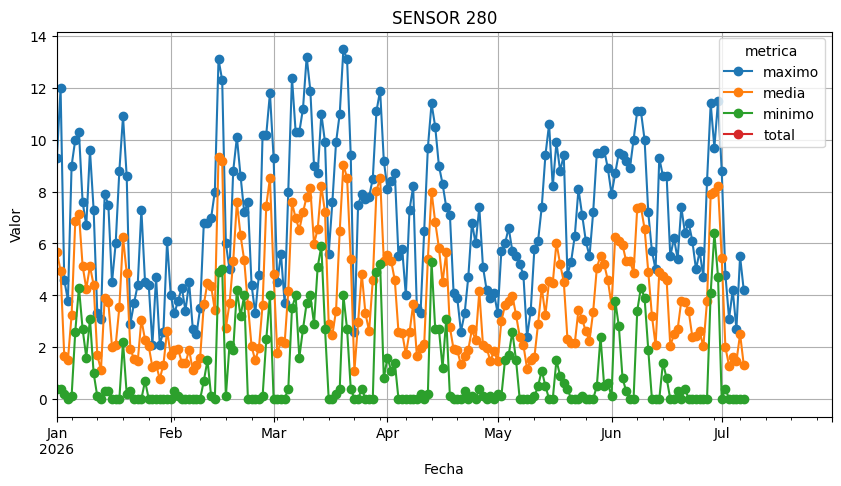

In [308]:
#Pivoteamos la tabla
df_sensor280_plot = df_sensor280.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
ax = df_sensor280_plot.plot(figsize=(10,5), marker='o')
ax.set_ylabel("Valor")
ax.set_xlabel("Fecha")
plt.title("SENSOR 280")
plt.grid(True)
plt.show()

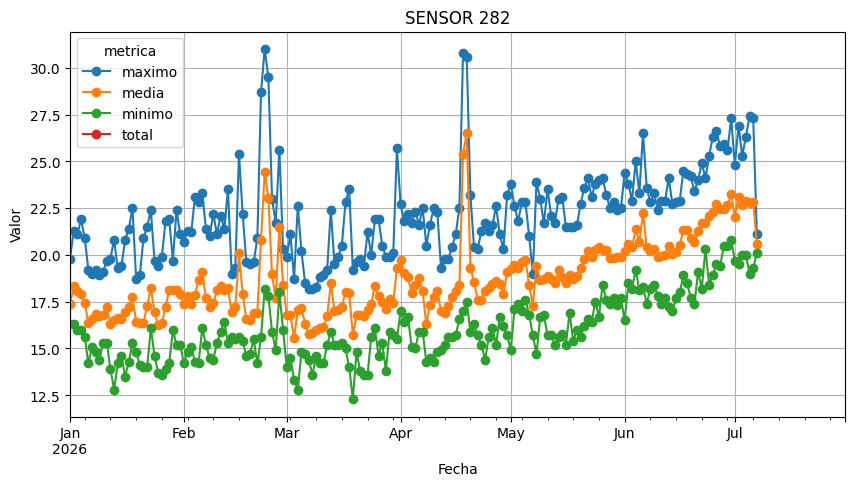

In [309]:
#Pivoteamos la tabla
df_sensor282_plot = df_sensor282.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
ax = df_sensor282_plot.plot(figsize=(10,5), marker='o')
ax.set_ylabel("Valor")
ax.set_xlabel("Fecha")
plt.title("SENSOR 282")
plt.grid(True)
plt.show()

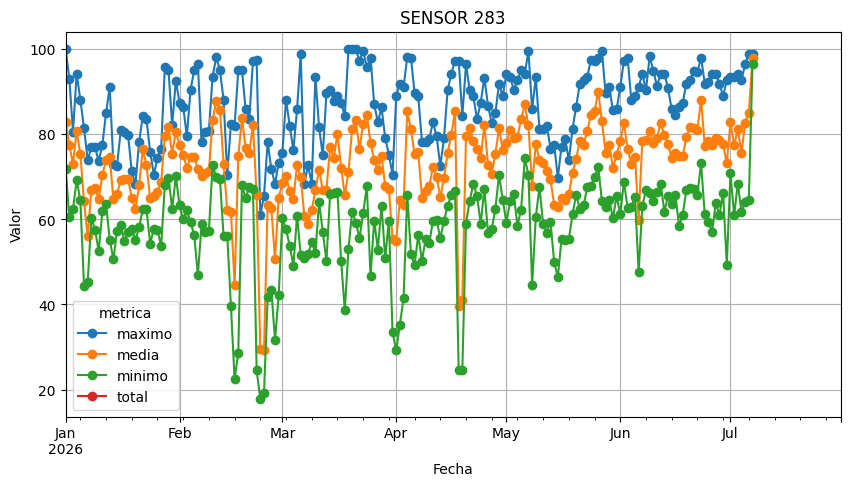

In [310]:
#Pivoteamos la tabla
df_sensor283_plot = df_sensor283.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
ax = df_sensor283_plot.plot(figsize=(10,5), marker='o')
ax.set_ylabel("Valor")
ax.set_xlabel("Fecha")
plt.title("SENSOR 283")
plt.grid(True)
plt.show()

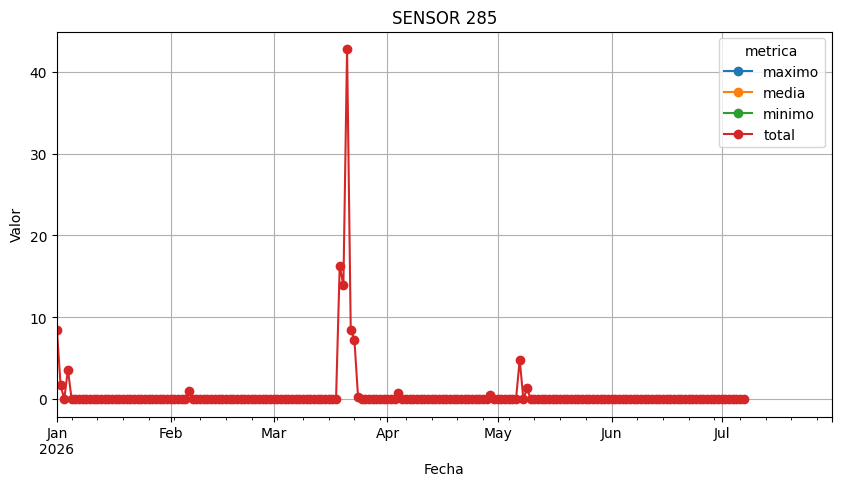

In [311]:
#Pivoteamos la tabla
df_sensor285_plot = df_sensor285.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
ax = df_sensor285_plot.plot(figsize=(10,5), marker='o')
ax.set_ylabel("Valor")
ax.set_xlabel("Fecha")
plt.title("SENSOR 285")
plt.grid(True)
plt.show()

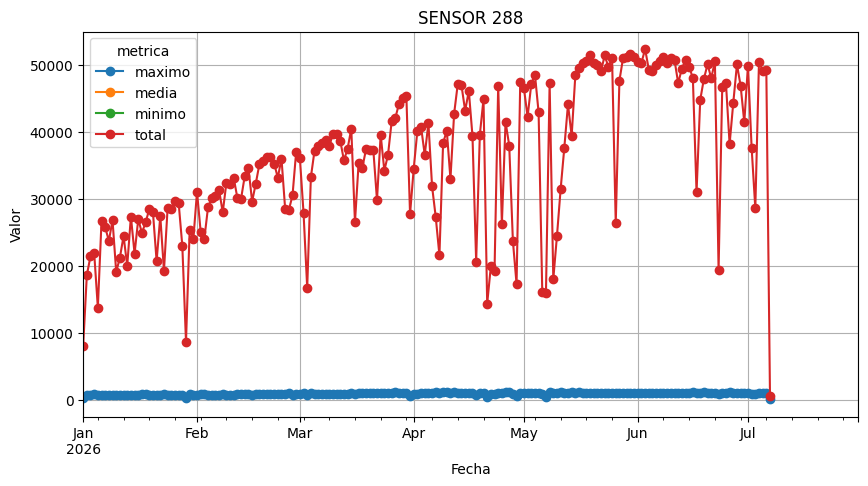

In [312]:
#Pivoteamos la tabla
df_sensor288_plot = df_sensor288.pivot(
    index='fecha_observacion',
    columns='metrica',
    values='valor'
)

#Graficamos
ax = df_sensor288_plot.plot(figsize=(10,5), marker='o')
ax.set_ylabel("Valor")
ax.set_xlabel("Fecha")
plt.title("SENSOR 288")
plt.grid(True)
plt.show()